# TikTok User Retention & Engagement Analysis
## Project Overview
Analysing user behaviour patterns, cohort retention, and engagement signals
using real-world transaction data as a proxy for consumer app behaviour.

**Tools:** Python, Pandas, Matplotlib, Seaborn, Tableau

**Dataset:** UCI Online Retail II — 805,549 transactions across 5,878 customers (Dec 2009 to Dec 2011)

**Key techniques:** Cohort analysis, retention heatmap, funnel analysis, user segmentation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

print("Libraries loaded ✅")

Libraries loaded ✅


In [3]:
!kaggle datasets download -d mashlyn/online-retail-ii-uci
!unzip online-retail-ii-uci.zip
!ls

Dataset URL: https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci
License(s): CC0-1.0
100% 14.5M/14.5M [00:00<00:00, 34.3MB/s]

Archive:  online-retail-ii-uci.zip
  inflating: online_retail_II.csv    
online_retail_II.csv  online-retail-ii-uci.zip	sample_data


In [4]:
df = pd.read_csv('online_retail_II.csv')

print(f"Total rows: {len(df):,}")
print(f"Columns: {df.columns.tolist()}")

Total rows: 1,067,371
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [5]:
print("First 5 rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nBasic stats:")
print(df.describe())

First 5 rows:
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  

Data types:
Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dt

In [6]:
df = df.dropna(subset=['Customer ID'])

df = df[df['Quantity'] > 0]

df = df[df['Price'] > 0]

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

print(f"Rows after cleaning: {len(df):,}")
print(f"\nDate range: {df['InvoiceDate'].min()} → {df['InvoiceDate'].max()}")
print(f"\nUnique customers: {df['Customer ID'].nunique():,}")

Rows after cleaning: 805,549

Date range: 2009-12-01 07:45:00 → 2011-12-09 12:50:00

Unique customers: 5,878


In [7]:
print("=== Final Dataset Info ===")
print(f"Shape: {df.shape}")

print(f"\nEvent breakdown (top countries):")
print(df['Country'].value_counts().head(5))

print(f"\nMonths in dataset:")
print(df['InvoiceMonth'].value_counts().sort_index())

print(f"\nUnique customers: {df['Customer ID'].nunique():,}")
print(f"Unique invoices: {df['Invoice'].nunique():,}")

=== Final Dataset Info ===
Shape: (805549, 9)

Event breakdown (top countries):
Country
United Kingdom    725250
Germany            16694
EIRE               15743
France             13812
Netherlands         5088
Name: count, dtype: int64

Months in dataset:
InvoiceMonth
2009-12    30754
2010-01    21775
2010-02    23367
2010-03    32301
2010-04    27235
2010-05    28644
2010-06    31188
2010-07    27032
2010-08    26392
2010-09    34599
2010-10    49561
2010-11    60312
2010-12    40661
2011-01    21229
2011-02    19927
2011-03    27175
2011-04    22642
2011-05    28320
2011-06    27185
2011-07    26825
2011-08    27007
2011-09    40028
2011-10    49554
2011-11    64531
2011-12    17305
Freq: M, Name: count, dtype: int64

Unique customers: 5,878
Unique invoices: 36,969


## Cohort Analysis
Customers are grouped by the month of their first purchase (cohort month).
Tracking how many return in subsequent months reveals retention patterns
and drop-off points over time. A cohort index of 0 represents the first
purchase month, with each subsequent index representing one additional month.

In [8]:
cohort_df = df.groupby('Customer ID')['InvoiceMonth'].min().reset_index()
cohort_df.columns = ['Customer ID', 'CohortMonth']

df = df.merge(cohort_df, on='Customer ID')

print(df[['Customer ID', 'InvoiceMonth', 'CohortMonth']].head(10))

   Customer ID InvoiceMonth CohortMonth
0      13085.0      2009-12     2009-12
1      13085.0      2009-12     2009-12
2      13085.0      2009-12     2009-12
3      13085.0      2009-12     2009-12
4      13085.0      2009-12     2009-12
5      13085.0      2009-12     2009-12
6      13085.0      2009-12     2009-12
7      13085.0      2009-12     2009-12
8      13085.0      2009-12     2009-12
9      13085.0      2009-12     2009-12


In [9]:
df['CohortIndex'] = (
    df['InvoiceMonth'].dt.to_timestamp() -
    df['CohortMonth'].dt.to_timestamp()
).dt.days // 30

print(df[['Customer ID', 'InvoiceMonth', 'CohortMonth', 'CohortIndex']].head(15))
print(f"\nMax cohort index: {df['CohortIndex'].max()}")

    Customer ID InvoiceMonth CohortMonth  CohortIndex
0       13085.0      2009-12     2009-12            0
1       13085.0      2009-12     2009-12            0
2       13085.0      2009-12     2009-12            0
3       13085.0      2009-12     2009-12            0
4       13085.0      2009-12     2009-12            0
5       13085.0      2009-12     2009-12            0
6       13085.0      2009-12     2009-12            0
7       13085.0      2009-12     2009-12            0
8       13085.0      2009-12     2009-12            0
9       13085.0      2009-12     2009-12            0
10      13085.0      2009-12     2009-12            0
11      13085.0      2009-12     2009-12            0
12      13078.0      2009-12     2009-12            0
13      13078.0      2009-12     2009-12            0
14      13078.0      2009-12     2009-12            0

Max cohort index: 24


In [10]:
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['Customer ID'].nunique().reset_index()

cohort_pivot = cohort_data.pivot_table(
    index='CohortMonth',
    columns='CohortIndex',
    values='Customer ID'
)

print(cohort_pivot.iloc[:5, :5])

CohortIndex      0      1      2      3      4
CohortMonth                                   
2009-12      955.0  337.0  319.0  406.0  363.0
2010-01      383.0  159.0    NaN  117.0  101.0
2010-02      374.0   84.0  109.0    NaN   92.0
2010-03      443.0   84.0  102.0  107.0  103.0
2010-04      294.0   57.0   57.0   48.0   54.0


In [11]:
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0).round(3) * 100

print(retention.iloc[:5, :5])

CohortIndex      0     1     2     3     4
CohortMonth                               
2009-12      100.0  35.3  33.4  42.5  38.0
2010-01      100.0  41.5   NaN  30.5  26.4
2010-02      100.0  22.5  29.1   NaN  24.6
2010-03      100.0  19.0  23.0  24.2  23.3
2010-04      100.0  19.4  19.4  16.3  18.4


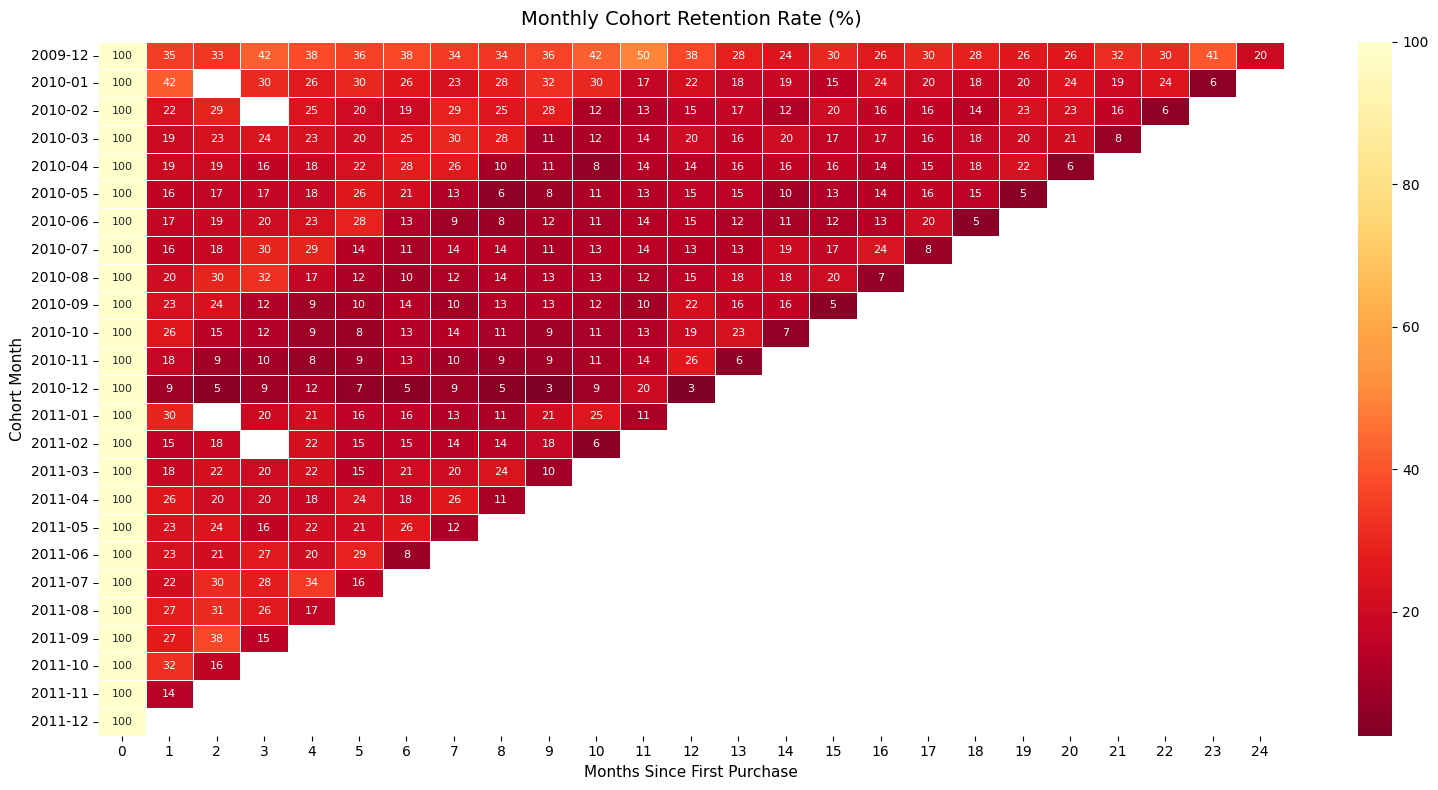

Chart saved!


In [12]:
plt.figure(figsize=(16, 8))

sns.heatmap(
    retention,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd_r',
    linewidths=0.5,
    annot_kws={'size': 8}
)

plt.title('Monthly Cohort Retention Rate (%)', fontsize=14, pad=12)
plt.xlabel('Months Since First Purchase', fontsize=11)
plt.ylabel('Cohort Month', fontsize=11)
plt.tight_layout()
plt.savefig('cohort_retention_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

### Finding
Retention drops sharply after the first purchase, with most cohorts retaining
15 to 35% of customers in month 1. However, customers who return after their
first purchase show relatively stable long-term retention, suggesting that
early re-engagement is the most critical window for reducing churn.

The December 2009 cohort shows the strongest retention across all time periods,
maintaining above 30% retention even at month 23.

## Funnel Analysis
Examining how many customers progress from a single purchase to repeated
purchases, identifying where the biggest drop-off in engagement occurs.

In [13]:
purchase_counts = df.groupby('Customer ID')['Invoice'].nunique().reset_index()
purchase_counts.columns = ['Customer ID', 'PurchaseCount']

print(purchase_counts['PurchaseCount'].describe())

count    5878.000000
mean        6.289384
std        13.009406
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max       398.000000
Name: PurchaseCount, dtype: float64


In [14]:
one_time = (purchase_counts['PurchaseCount'] == 1).sum()
occasional = ((purchase_counts['PurchaseCount'] >= 2) &
              (purchase_counts['PurchaseCount'] <= 4)).sum()
regular = ((purchase_counts['PurchaseCount'] >= 5) &
           (purchase_counts['PurchaseCount'] <= 9)).sum()
loyal = (purchase_counts['PurchaseCount'] >= 10).sum()

total = len(purchase_counts)

funnel = pd.DataFrame({
    'Stage': ['One-time buyers', 'Occasional (2-4)', 'Regular (5-9)', 'Loyal (10+)'],
    'Customers': [one_time, occasional, regular, loyal],
    'Percentage': [
        round(one_time/total*100, 1),
        round(occasional/total*100, 1),
        round(regular/total*100, 1),
        round(loyal/total*100, 1)
    ]
})

print(funnel)

              Stage  Customers  Percentage
0   One-time buyers       1623        27.6
1  Occasional (2-4)       2094        35.6
2     Regular (5-9)       1187        20.2
3       Loyal (10+)        974        16.6


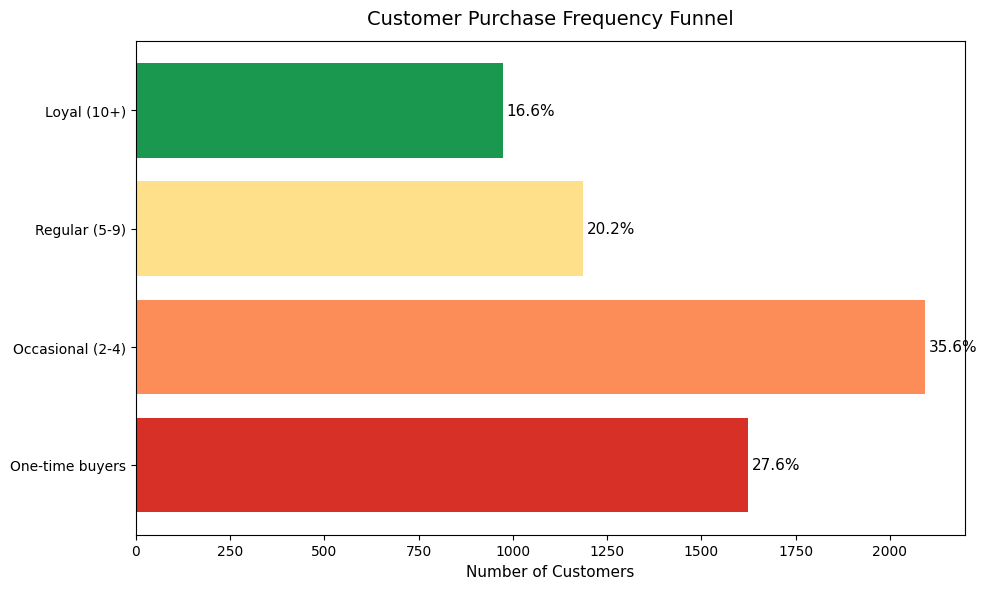

Chart saved!


In [15]:
plt.figure(figsize=(10, 6))

colors = ['#d73027', '#fc8d59', '#fee08b', '#1a9850']

bars = plt.barh(funnel['Stage'], funnel['Customers'], color=colors)

for i, (customers, pct) in enumerate(zip(funnel['Customers'], funnel['Percentage'])):
    plt.text(customers + 10, i, f'{pct}%', va='center', fontsize=11)

plt.title('Customer Purchase Frequency Funnel', fontsize=14, pad=12)
plt.xlabel('Number of Customers', fontsize=11)
plt.tight_layout()
plt.savefig('purchase_funnel.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

### Finding
27.6% of customers made only one purchase and never returned, representing
the largest single drop-off point in the engagement funnel. The majority of
customers fall into the occasional buyer segment (35.6%), suggesting that
converting occasional buyers into regular ones is the highest leverage
opportunity for improving retention. Only 16.6% of customers reach loyal
status with 10 or more purchases.

## User Segmentation
Segmenting customers into behavioural groups based on purchase frequency
to understand what separates loyal customers from one-time buyers.

In [16]:
def assign_segment(count):
    if count == 1:
        return 'One-time'
    elif count <= 4:
        return 'Occasional'
    elif count <= 9:
        return 'Regular'
    else:
        return 'Loyal'

purchase_counts['Segment'] = purchase_counts['PurchaseCount'].apply(assign_segment)

df = df.merge(purchase_counts[['Customer ID', 'Segment', 'PurchaseCount']], on='Customer ID')

print(df[['Customer ID', 'Segment', 'PurchaseCount']].drop_duplicates().head(10))

     Customer ID     Segment  PurchaseCount
0        13085.0     Regular              8
12       13078.0       Loyal             57
31       15362.0  Occasional              2
54       18102.0       Loyal            145
71       12682.0       Loyal             52
90       18087.0       Loyal             17
96       13635.0  Occasional              4
119      14110.0       Loyal             33
126      12636.0    One-time              1
127      17519.0       Loyal             15


In [17]:
df['TotalSpend'] = df['Quantity'] * df['Price']

segment_summary = df.groupby('Segment').agg(
    AvgPurchaseCount=('PurchaseCount', 'mean'),
    AvgSpendPerTransaction=('TotalSpend', 'mean'),
    TotalCustomers=('Customer ID', 'nunique')
).round(2).reset_index()

segment_order = ['One-time', 'Occasional', 'Regular', 'Loyal']
segment_summary['Segment'] = pd.Categorical(segment_summary['Segment'], categories=segment_order, ordered=True)
segment_summary = segment_summary.sort_values('Segment')

print(segment_summary)

      Segment  AvgPurchaseCount  AvgSpendPerTransaction  TotalCustomers
2    One-time              1.00                   16.02            1623
1  Occasional              3.01                   17.75            2094
3     Regular              6.90                   16.76            1187
0       Loyal             54.25                   25.65             974


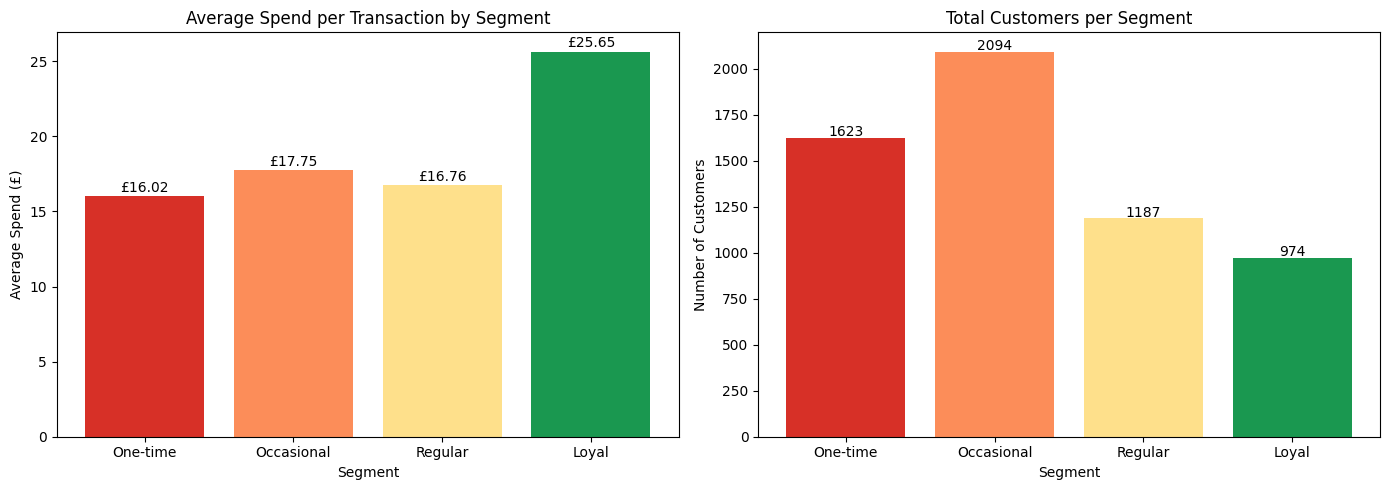

Chart saved!


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#d73027', '#fc8d59', '#fee08b', '#1a9850']

axes[0].bar(segment_summary['Segment'], segment_summary['AvgSpendPerTransaction'], color=colors)
axes[0].set_title('Average Spend per Transaction by Segment', fontsize=12)
axes[0].set_xlabel('Segment', fontsize=10)
axes[0].set_ylabel('Average Spend (£)', fontsize=10)
for i, v in enumerate(segment_summary['AvgSpendPerTransaction']):
    axes[0].text(i, v + 0.3, f'£{v}', ha='center', fontsize=10)

axes[1].bar(segment_summary['Segment'], segment_summary['TotalCustomers'], color=colors)
axes[1].set_title('Total Customers per Segment', fontsize=12)
axes[1].set_xlabel('Segment', fontsize=10)
axes[1].set_ylabel('Number of Customers', fontsize=10)
for i, v in enumerate(segment_summary['TotalCustomers']):
    axes[1].text(i, v + 10, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('segment_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

### Finding
Loyal customers spend an average of £25.65 per transaction, compared to £16.02
for one-time buyers, representing a 60% higher average transaction value.
Despite being the smallest segment by customer count (974), loyal customers
likely drive a disproportionate share of total revenue. The largest segment
is occasional buyers (2,094 customers), representing the biggest opportunity
for conversion into higher value segments through targeted re-engagement.